## Churn Analysis and Customer Intelligence

In [498]:
# Churn Analysis and Customer Intelligence

In [499]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Import database / data  

In [500]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""
# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [501]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


## 2. Data cleaning

In [502]:
df_db_customer.head(10) # customer table
# df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,NaN
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,NaN
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,NaN
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,NaN


In [503]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  521 non-null    str    
 1   name        521 non-null    str    
 2   country     518 non-null    str    
 3   state       521 non-null    str    
 4   gender      521 non-null    str    
 5   dob         521 non-null    str    
 6   interests   437 non-null    str    
 7   pincode     153 non-null    float64
dtypes: float64(1), str(7)
memory usage: 61.8 KB


In [504]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

#### a. Rename Col

In [505]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN
...,...,...,...,...,...,...,...,...
516,0517-AULBW,ananya,USA,Texas,Women,1987-06-06 00:00:00,cooking,NaN
517,0518-SNSHU,arjun,Australia,Victoria,Male,1997-03-18 00:00:00,NaN,NaN
518,0519-DFTUQ,aarav,Germany,Berlin,Man,1975-06-05 00:00:00,NaN,NaN
519,0520-THXHK,james,Australia,Victoria,Man,1999-11-10 00:00:00,movie,188320.0


#### b. Drop columns

In [506]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1) #using -ve index from right
# df_db_customer.drop(df_db_customer.columns[6:], axis=1) #using +ve index from left

df_db_customer.drop(columns=['interests', 'pincode'],inplace= True)  # using col nam

In [507]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     521 non-null    str  
 1   customer_name  521 non-null    str  
 2   country        518 non-null    str  
 3   state          521 non-null    str  
 4   gender         521 non-null    str  
 5   dob            521 non-null    str  
dtypes: str(6)
memory usage: 51.0 KB


#### c. Change data type

In [508]:
# c. change data type - dob

df_db_customer['dob'] =df_db_customer['dob'].apply(pd.to_datetime)

In [509]:
df_db_customer.dtypes

customerid                  str
customer_name               str
country                     str
state                       str
gender                      str
dob              datetime64[us]
dtype: object

#### d. Data standardization

In [523]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Man' : 'Male', 'Women' : 'Female'})

In [524]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

#### e. Fix missing values

In [525]:
# e. fix missing values - country

#df_db_customer['country'].isna().sum() #Count missing values
df_db_customer[df_db_customer['country'].isna()] #Show rows with missing values

,customerid,customer_name,country,state,gender,dob


In [526]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [527]:
df_db_customer[df_db_customer['country'].isna()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [528]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
...,...,...
516,USA,Texas
517,Australia,Victoria
518,Germany,Berlin
519,Australia,Victoria


In [529]:
df_db_subscription.head(10) # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41


In [530]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               521 non-null    str           
 1   subscription_start_date  521 non-null    datetime64[us]
 2   subscription_type        521 non-null    str           
 3   renewal_date             521 non-null    datetime64[us]
 4   plan_type                521 non-null    str           
 5   contract_type            521 non-null    str           
 6   cancellation_date        95 non-null     datetime64[us]
 7   cancellation_reason      95 non-null     str           
 8   monthly_charges          521 non-null    float64       
 9   cltv                     521 non-null    int64         
 10  churn_score              521 non-null    int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 61.5 KB


In [531]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               521 non-null    str           
 1   subscription_start_date  521 non-null    datetime64[us]
 2   subscription_type        521 non-null    str           
 3   renewal_date             521 non-null    datetime64[us]
 4   plan_type                521 non-null    str           
 5   contract_type            521 non-null    str           
 6   cancellation_date        95 non-null     datetime64[us]
 7   cancellation_reason      95 non-null     str           
 8   monthly_charges          521 non-null    float64       
 9   cltv                     521 non-null    int64         
 10  churn_score              521 non-null    int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 61.5 KB


In [532]:
df_db_support.head(10) # support table

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90
9,0022-YAXXQ,2026-04-06,N,40


In [533]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      315 non-null    str           
 1   complaint_date  315 non-null    datetime64[us]
 2   escalations     315 non-null    str           
 3   csat_score      315 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 13.4 KB


In [534]:
# drop columns
df_db_support.drop(columns=['col_1', 'comment'], inplace=True ,errors='ignore')

In [535]:
# change data type to date - complaint_date
df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(pd.to_datetime) #both method used to change data type
#df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      315 non-null    str           
 1   complaint_date  315 non-null    datetime64[us]
 2   escalations     315 non-null    str           
 3   csat_score      315 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 13.4 KB


## 3. Feature Engineering & Data Analysis

In [536]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [537]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df =(df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [538]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     521 non-null    str           
 1   customer_name  521 non-null    str           
 2   country        521 non-null    str           
 3   state          521 non-null    str           
 4   gender         521 non-null    str           
 5   dob            521 non-null    datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 41.5 KB


In [539]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               521 non-null    str           
 1   subscription_start_date  521 non-null    datetime64[us]
 2   subscription_type        521 non-null    str           
 3   renewal_date             521 non-null    datetime64[us]
 4   plan_type                521 non-null    str           
 5   contract_type            521 non-null    str           
 6   cancellation_date        95 non-null     datetime64[us]
 7   cancellation_reason      95 non-null     str           
 8   monthly_charges          521 non-null    float64       
 9   cltv                     521 non-null    int64         
 10  churn_score              521 non-null    int64         
 11  churn_flag               521 non-null    int64         
dtypes: datetime64[us](3), float64(1), int64(3), str

In [540]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      315 non-null    str           
 1   complaint_date  315 non-null    datetime64[us]
 2   escalations     315 non-null    str           
 3   csat_score      315 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 13.4 KB


In [541]:
df.info() # 20 bcz customerid repates 2 times

<class 'pandas.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               523 non-null    str           
 1   subscription_start_date  523 non-null    datetime64[us]
 2   subscription_type        523 non-null    str           
 3   renewal_date             523 non-null    datetime64[us]
 4   plan_type                523 non-null    str           
 5   contract_type            523 non-null    str           
 6   cancellation_date        97 non-null     datetime64[us]
 7   cancellation_reason      97 non-null     str           
 8   monthly_charges          523 non-null    float64       
 9   cltv                     523 non-null    int64         
 10  churn_score              523 non-null    int64         
 11  churn_flag               523 non-null    int64         
 12  customer_name            523 non-null    str   

In [542]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 521
df_db_customer unique value: 521
df_db_support unique value: 313
df_db_support all value: 315


In [543]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
310,0513-QYMNP,2025-08-07,Y,100
311,0514-OYBHM,2023-10-05,Y,60
312,0515-UZFGC,2024-08-15,N,10
313,0518-SNSHU,2027-08-27,Y,100


In [544]:
df_db_support['complaint_count'] = (
    df_db_support.groupby('customerid')['customerid']
    .transform('count')
)

In [545]:
df_db_support = (
    df_db_support
    .sort_values('complaint_date')
    .drop_duplicates('customerid', keep='last')
)

In [546]:
df_db_support['customerid'].size

313

In [547]:
# Merge subscription + customer + support
df = (
    df_db_subscription
        .merge(df_db_customer, on='customerid', how='left')
        .merge(df_db_support, on='customerid', how='left')
)

In [548]:
df.shape

(521, 21)

#### Export dataframe

In [549]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

In [550]:
print(df.columns)

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')


## Data Analysis

In [551]:
# 1. Churn Rate

In [552]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  18.23 %


In [553]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  81.77 %


In [554]:
# 3. Churn by Plan type
#churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
churn_by_plan = (
    df.groupby('plan_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          revenue_loss=('monthly_charges', lambda x: x[df.loc[x.index, 'churn_flag'] == 1].sum()),
          churned_users=('churn_flag', 'sum')
      )
      .reset_index()
)
print(churn_by_plan)

  plan_type  churn_rate_pct  revenue_loss  churned_users
0     Basic           17.50        363.72             28
1   Premium           20.47        457.65             35
2  Standard           16.84        432.68             32


In [557]:
# 4a. Churn by State + Revenue + Churned_Users and Churn_Rate

state_data = df.groupby("state").agg(
    Total_Users=("customerid", "count"),
    Revenue=("monthly_charges", "sum"),
    Churned_Users=("churn_flag", "sum")
).reset_index()

# Churn Rate
state_data["Churn_Rate"] = (
    state_data["Churned_Users"] / state_data["Total_Users"] * 100
).round(2)

print(state_data)


            state  Total_Users  Revenue  Churned_Users  Churn_Rate
0         Bavaria           50   638.50             14       28.00
1          Berlin           52   675.48             10       19.23
2      California           32   432.68              7       21.88
3           Delhi           22   264.78              2        9.09
4         Florida           26   330.74              1        3.85
5         Gujarat           22   251.78              2        9.09
6       Karnataka           28   355.72              6       21.43
7       Kathmandu            2    20.98              0        0.00
8     Maharashtra           21   247.79              6       28.57
9       Meghalaya            3    42.97              2       66.67
10            NSW           47   555.53             10       21.28
11       Nagaland            1    22.99              0        0.00
12        Ontario           63   873.37              7       11.11
13         Quebec           48   619.52             10       2

In [558]:
# 4 b. Churn by subscription type + sum(revenue) & count of users
# Churn (Yes/No)
df_db_subscription['churn'] = df_db_subscription['cancellation_date'].notna()

# Group by subscription type
result = df_db_subscription.groupby('subscription_type').agg({
    'customerid': 'count',
    'monthly_charges': 'sum',
    'churn': 'sum'
})

# Rename columns
result.columns = ['total_users', 'total_revenue', 'churned_users']

# Churn rate
result['churn_rate'] = (result['churned_users'] / result['total_users'] * 100).round(2)

print(result)

                   total_users  total_revenue  churned_users  churn_rate
subscription_type                                                       
Organic                    168        2139.32             27       16.07
Paid                       169        2243.31             31       18.34
Refferal                   184        2382.16             37       20.11


In [559]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  12.98


In [560]:
#calculate customer age
today =pd.Timestamp.today()
#customer_age = ((today - df['dob']).dt.days / 365).astype(int)
customer_age = (today-df['dob']).dt.days//365   # // gives whole value 
print("customer age is", customer_age)
 

customer age is 0      44
1      30
2      48
3      25
4      36
       ..
516    39
517    29
518    51
519    26
520    26
Name: dob, Length: 521, dtype: int64


In [561]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1446 0


In [562]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'k') =", revenue_at_risk)

Revenue at Risk (Rs 'k') = 1254.05


In [563]:
# 8. Esclation Rate
# Escalation Rate
escalation_rate = (df_db_support['escalations'] == 'Y').mean() * 100

print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 50.48 %


In [564]:
df_db_support.info()

<class 'pandas.DataFrame'>
Index: 313 entries, 163 to 86
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customerid       313 non-null    str           
 1   complaint_date   313 non-null    datetime64[us]
 2   escalations      313 non-null    str           
 3   csat_score       313 non-null    int64         
 4   complaint_count  313 non-null    int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 18.1 KB


In [565]:
print(df.columns)

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')


In [566]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.6


In [567]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.01


In [568]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

## 4. Visualization using Matplotlib

In [569]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [570]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

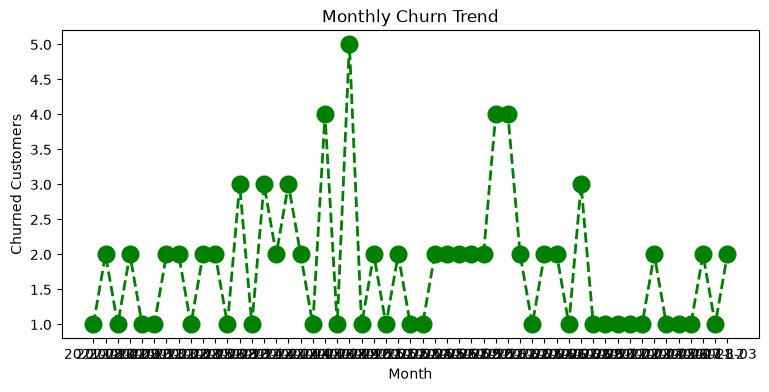

In [571]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(9,4))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12) 
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

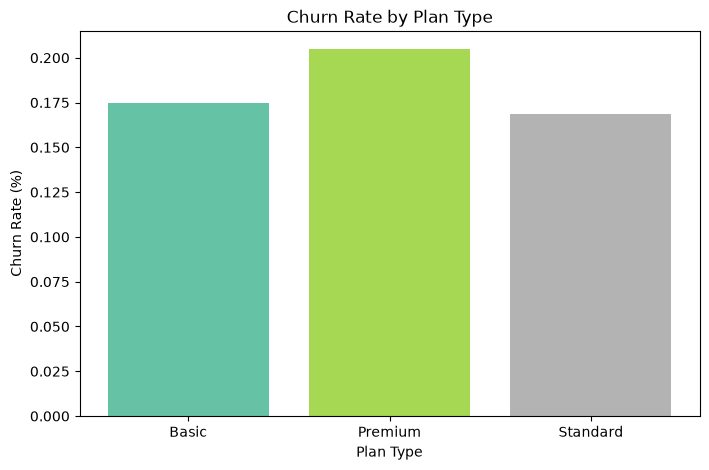

In [572]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan))) #dynamic colors , random clors

plt.figure(figsize=(8,5))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

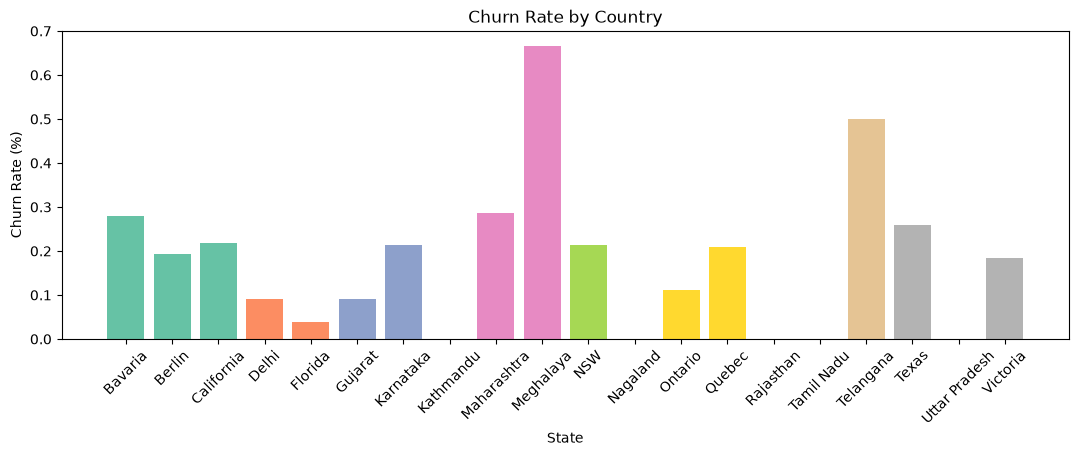

In [573]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(13,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## Visulaization using Seaborn

In [574]:
# Heatmap (Correlation Matrix)

In [575]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [576]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].tail(6)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
515,Basic,Annual,29,0,low,0
516,Standard,Annual,99,1,high,0
517,Premium,Monthly,98,0,high,1
518,Standard,Annual,27,0,low,0
519,Premium,Monthly,60,0,med,0
520,Basic,Monthly,30,0,low,1


In [577]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [578]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [579]:
df_encoded.tail(6)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
515,0,0,29,0,1,0
516,2,0,99,1,0,0
517,1,1,98,0,0,1
518,2,0,27,0,1,0
519,1,1,60,0,2,0
520,0,1,30,0,1,1


<Axes: >

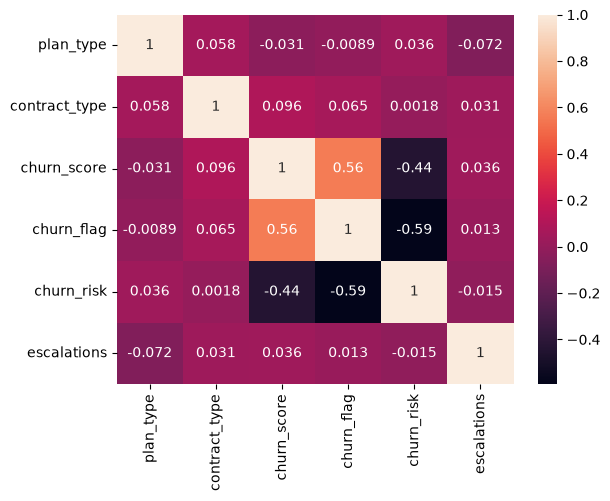

In [580]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [581]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <ArrowStringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <ArrowStringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <ArrowStringArray>
['low', 'high', 'med']
Length: 3, dtype: str


In [582]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [583]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].tail(6)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
515,Basic,Annual,29,0,low,0
516,Standard,Annual,99,1,high,0
517,Premium,Monthly,98,0,high,1
518,Standard,Annual,27,0,low,0
519,Premium,Monthly,60,0,med,0
520,Basic,Monthly,30,0,low,1


In [584]:
df_encoded.tail(6)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
515,0,1,29,0,0,0
516,1,1,99,1,2,0
517,2,0,98,0,2,1
518,1,1,27,0,0,0
519,2,0,60,0,1,0
520,0,0,30,0,0,1


<Axes: >

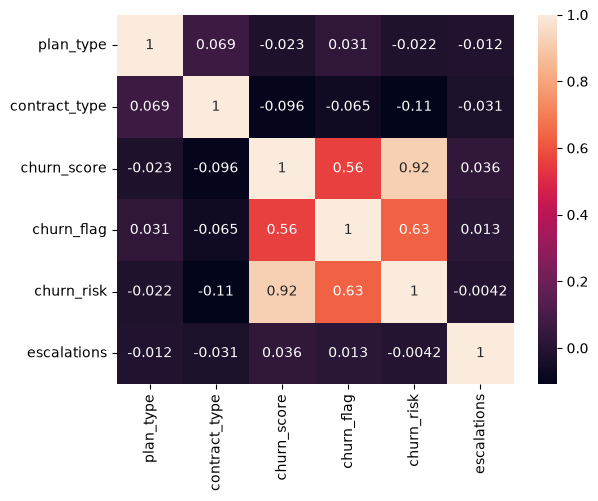

In [585]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

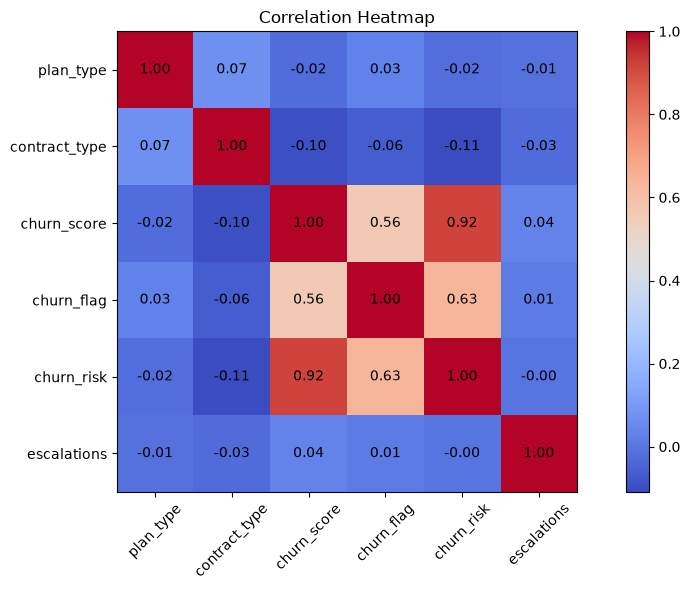

In [586]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

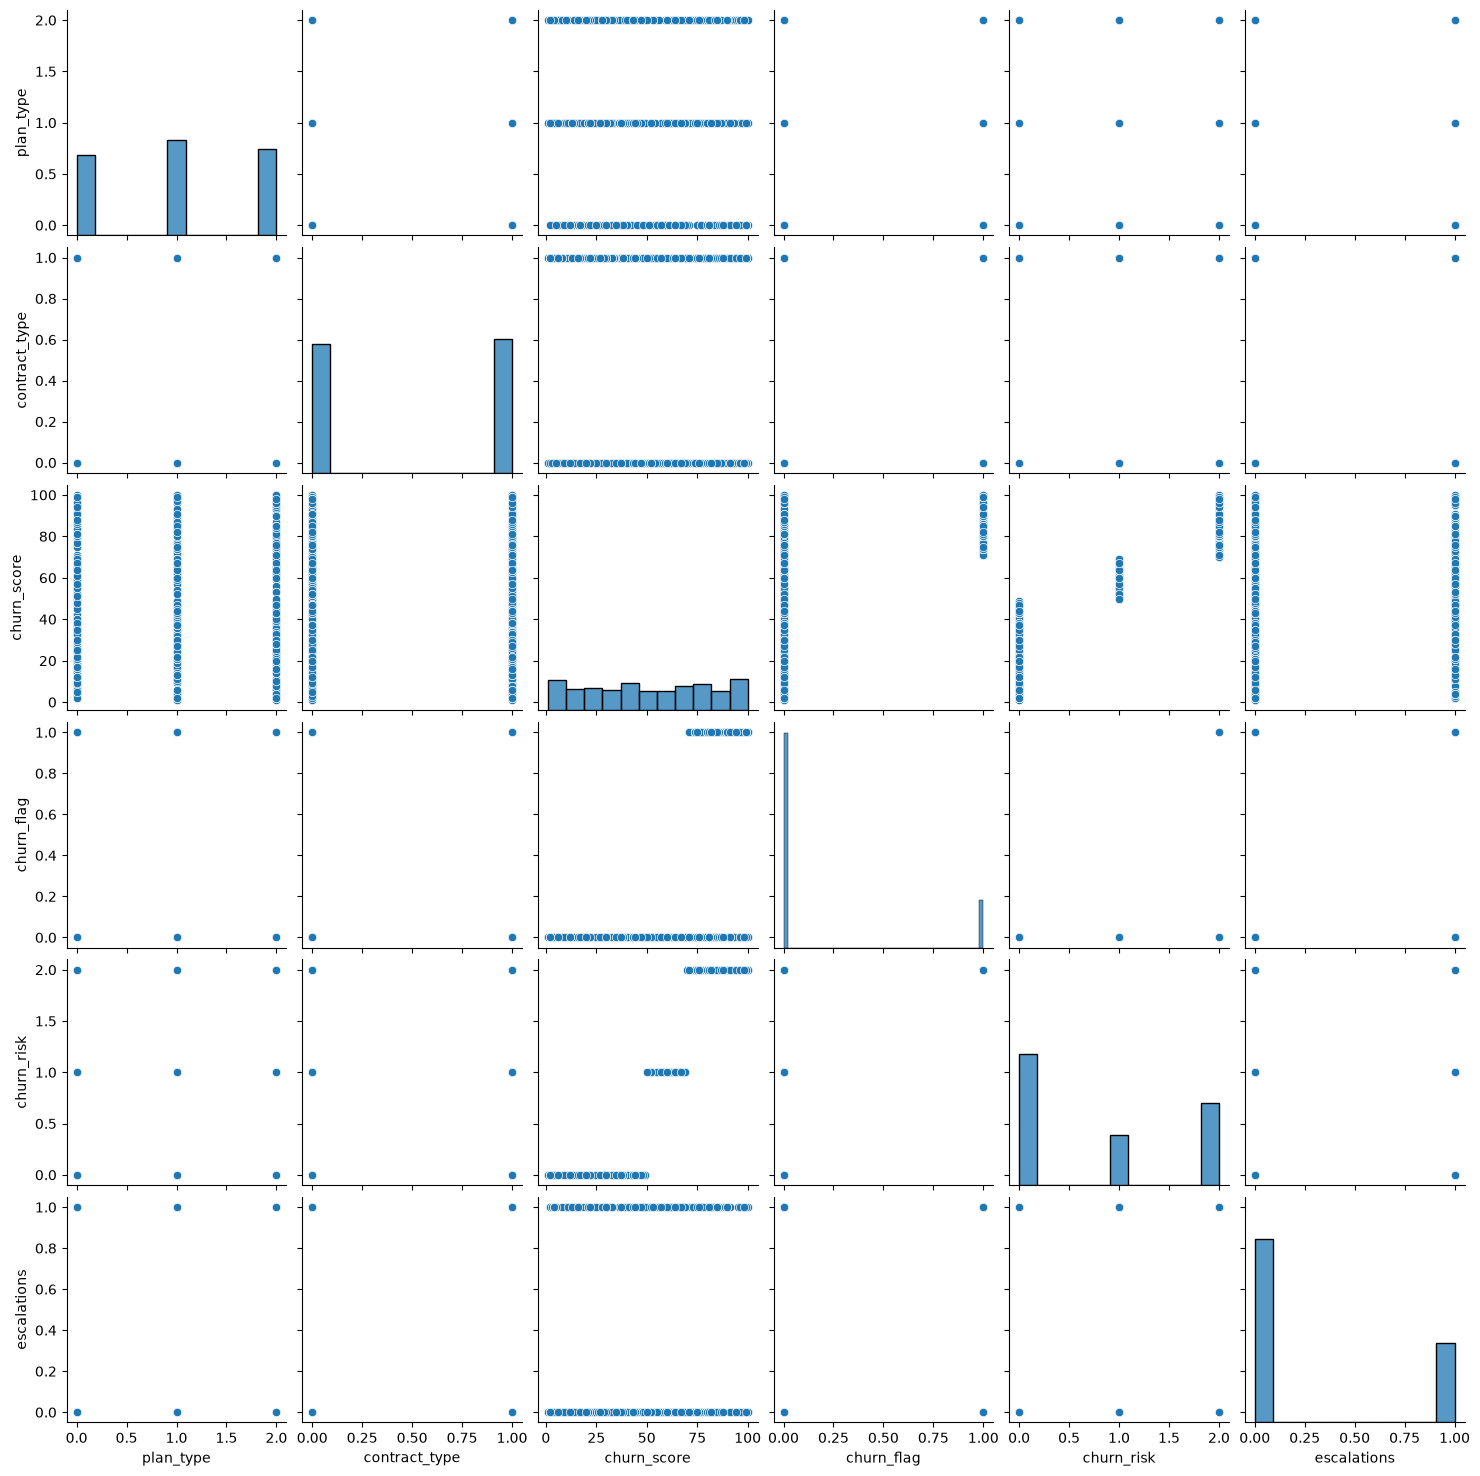

In [587]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [588]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

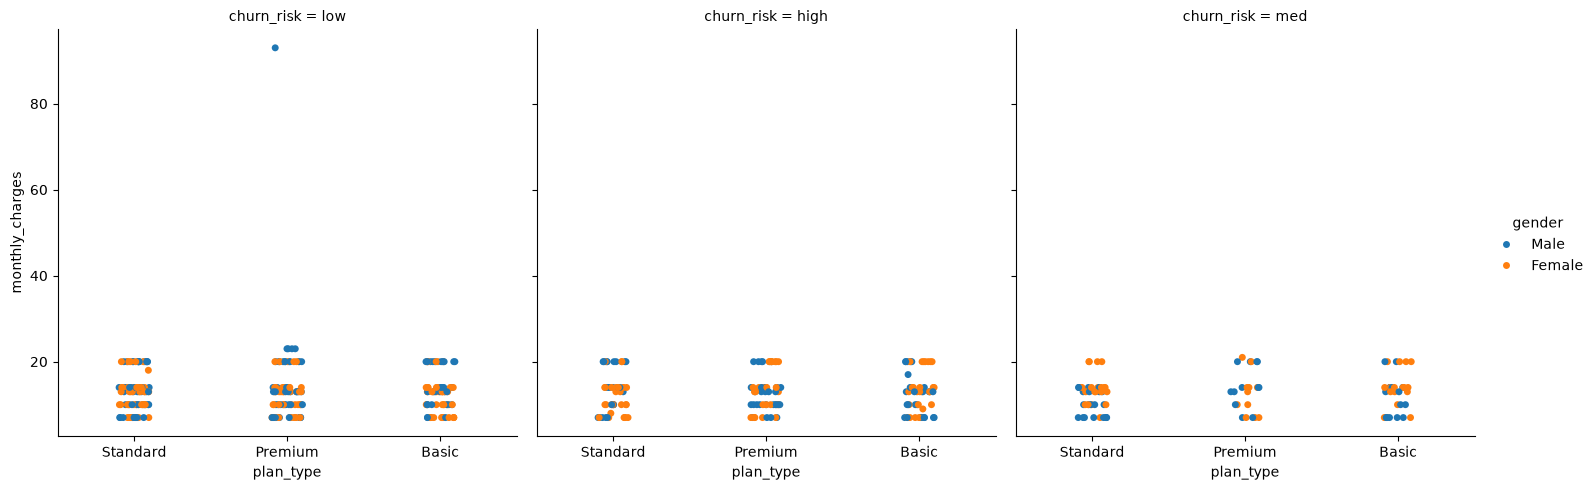

In [589]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

## Pivot table

In [590]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.175000
Premium,0.204678
Standard,0.168421


In [591]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.175000,160,2060.40
Premium,0.204678,171,2302.29
Standard,0.168421,190,2402.10


In [593]:
df.to_csv("customer_churn_cleaned.csv", index=False)

In [594]:
df_visual.shape

(521, 24)

## Project Completed :)

## Working with SQL in Python

In [73]:
# create db in sql
conn = sqlite3.connect('x_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

print("Cretaed Table successfully!")

Cretaed Table successfully!


In [74]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users  (first_name, country, budget) VALUES
            ('Anurag', 'India', 9000),
            ('Aditya', 'Germany', 5000),
            ('Shyam', 'India', 3500),
            ('Ananya', 'Canada', 4200),
            ('Rahul', 'India', 2800),
            ('Priya', 'Australia', 6100),
            ('Karan', 'USA', 4700),
            ('Sneha', 'India', 3900),
            ('Arjun', 'UK', 5200),
            ('Neha', 'Singapore', 4500)
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [76]:
# check inserted data in table
conn = sqlite3.connect('x_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Anurag,India,9000
1,Aditya,Germany,5000
2,Shyam,India,3500
3,Ananya,Canada,4200
4,Rahul,India,2800


In [78]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Australia,6100
1,Canada,4200
2,Germany,5000
3,India,19200
4,Singapore,4500
5,UK,5200
6,USA,4700


In [79]:
# always close the conn with db once the task is over
conn.close()